# Shower rates v1.2

In [5]:
import uproot
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

import sys
sys.path.append("../")
from utils.py_plot_functions import plot_station_wheel_profile
from utils.functions import stations, wheels

plt.style.use(hep.styles.CMS)

In [3]:
histos_mb_v1 = uproot.open("histograms/histograms_mb_v1.root")
histos_mb_v1p2 = uproot.open("histograms/histograms_mb_v1p2.root")

mb_v1_nevents = 1994560
mb_v1p2_nevents = 1994560

Luminosity = 2760 * 11246  # in pb^-1

In [6]:
v1_data = []
v1p2_data = []
v1_gbx_data = []
v1p2_gbx_data = []
am_v1p2_data = []
am_v1p2_gbx_data = []

tick_positions = []
tick_labels = []

for st in stations:
    for wh in wheels:
        key = "nshowers_wh{wh}_st{st}{GOODBX};1"

        v1_data.append(histos_mb_v1[key.format(wh=wh, st=st, GOODBX="")].to_hist().sum() * 1 / mb_v1_nevents * Luminosity)
        v1p2_data.append(histos_mb_v1p2[key.format(wh=wh, st=st, GOODBX="")].to_hist().sum() * 1 / mb_v1p2_nevents * Luminosity)
        v1_gbx_data.append(histos_mb_v1[key.format(wh=wh, st=st, GOODBX="_goodBX")].to_hist().sum() * 1 / mb_v1_nevents * Luminosity)
        v1p2_gbx_data.append(histos_mb_v1p2[key.format(wh=wh, st=st, GOODBX="_goodBX")].to_hist().sum() * 1 / mb_v1p2_nevents * Luminosity)

        key_am = "nAMtps_phi{GOODBX}_wh{wh}_st{st}_q{q};1"
        
        am_v1p2_data.append(sum([histos_mb_v1p2[key_am.format(wh=wh, st=st, GOODBX="", q=q)].to_hist() for q in [-1, 1, 2, 3, 4, 6, 7, 8]]).sum() * 1 / mb_v1p2_nevents * Luminosity)
        am_v1p2_gbx_data.append(sum([histos_mb_v1p2[key_am.format(wh=wh, st=st, GOODBX="_goodBX", q=q)].to_hist() for q in [-1, 1, 2, 3, 4, 6, 7, 8]]).sum() * 1 / mb_v1p2_nevents * Luminosity)


### Shower rates

[]

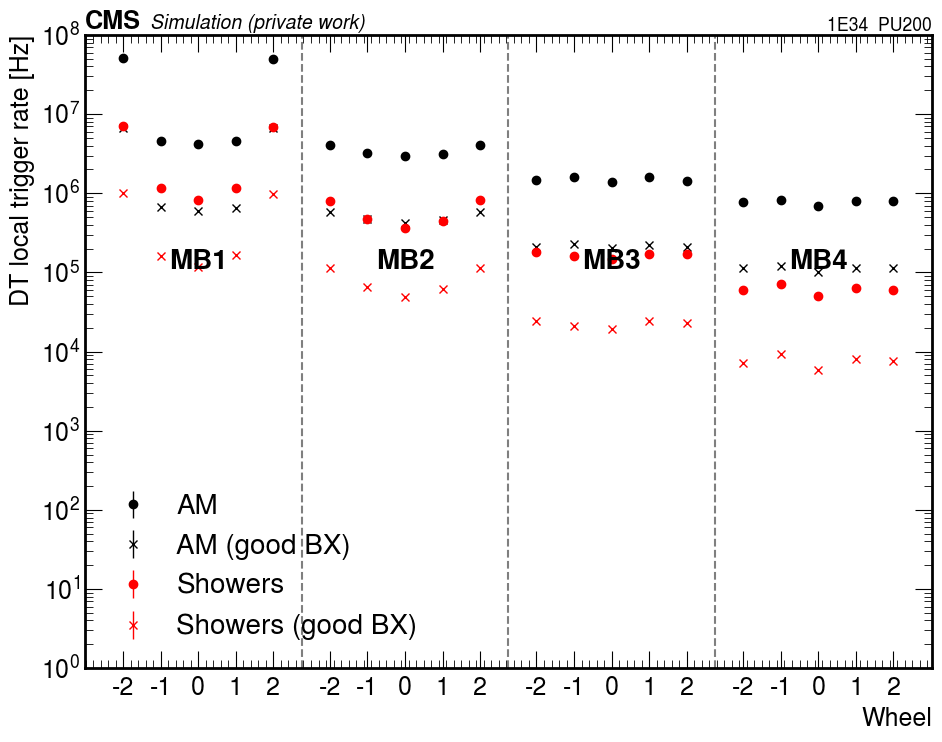

In [9]:
profile_plot_kwargs = {
    "st_label_y": 1e5,
    "st_labels_kwargs": {"fontsize": 20, "fontweight": "bold", "ha": "center"},
    "tick_params_kwargs": {"labelsize": 18},
    "cms_label_kwargs": {"text": "(private work)", "data": False, "rlabel": "1E34  PU200", "fontsize": 14},
    "xlabel_kwargs": {"fontsize": 12},
}

fig, ax = plt.subplots(figsize=(10, 8))

plot_station_wheel_profile(
    am_v1p2_data, 
    ax=ax, 
    errors=None, 
    plot_kwargs={"label": "AM", "fmt": "o", "color": "k", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    am_v1p2_gbx_data, 
    ax=ax, 
    errors=None, 
    plot_kwargs={"label": "AM (good BX)", "fmt": "x", "color": "k", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    v1p2_data, 
    ax=ax, 
    errors=None, 
    plot_kwargs={"label": "Showers", "fmt": "o", "color": "red", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    v1p2_gbx_data, 
    ax=ax, 
    errors=None, 
    plot_kwargs={"label": "Showers (good BX)", "fmt": "x", "color": "red", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)

ax.set_yscale('log')
ax.set_ylim(1, 1e8)
ax.set_ylabel("DT local trigger rate [Hz]", fontsize=18)
ax.set_xlabel("Wheel", fontsize=18)

ax.legend(loc='best', fontsize=20)
plt.tight_layout()

plt.plot()

### versions comparison

[]

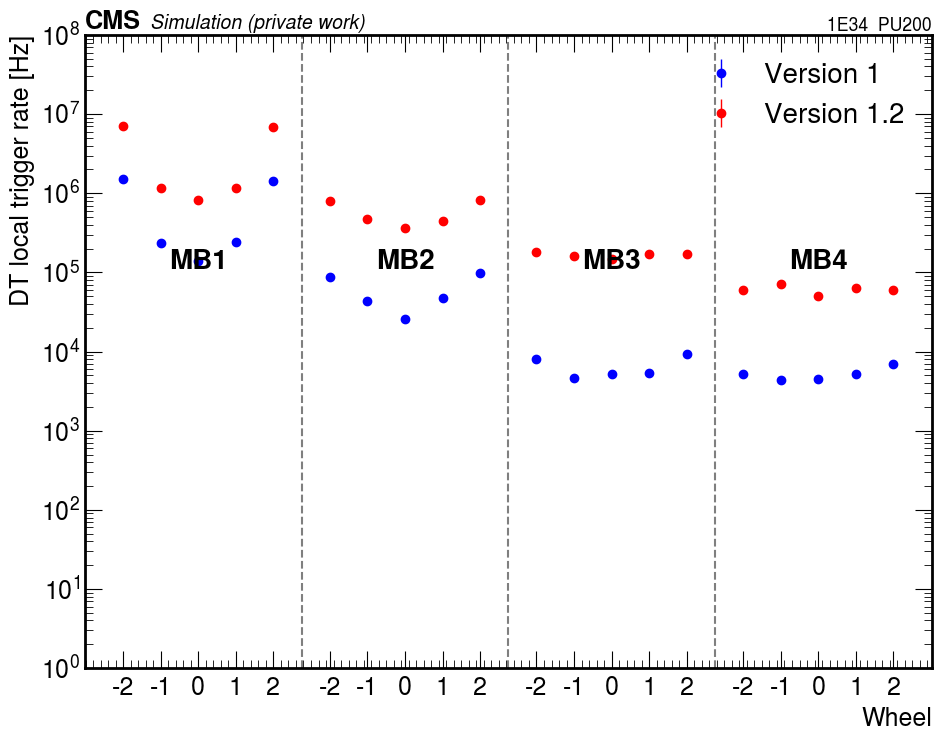

In [10]:
profile_plot_kwargs = {
    "st_label_y": 1e5,
    "st_labels_kwargs": {"fontsize": 20, "fontweight": "bold", "ha": "center"},
    "tick_params_kwargs": {"labelsize": 18},
    "cms_label_kwargs": {"text": "(private work)", "data": False, "rlabel": " 1E34  PU200", "fontsize": 14},
    "xlabel_kwargs": {"fontsize": 12},
}

fig, ax = plt.subplots(figsize=(10, 8))

plot_station_wheel_profile(
    v1_data, 
    ax=ax, 
    errors=None, 
    plot_kwargs={"label": "Version 1", "fmt": "o", "color": "b", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    v1p2_data, 
    ax=ax, 
    errors=None, 
    plot_kwargs={"label": "Version 1.2", "fmt": "o", "color": "red", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)

ax.set_yscale('log')
ax.set_ylim(1, 1e8)
ax.set_ylabel("DT local trigger rate [Hz]", fontsize=18)
ax.set_xlabel("Wheel", fontsize=18)

ax.legend(loc='best', fontsize=20)
plt.tight_layout()

plt.plot()